In [22]:
import torch
from torchvision import transforms
from face_alignment import align

path = 'data/hacker_house/DSC03170.jpg'
aligned = align.get_aligned_faces(path) # align face


In [24]:
import matplotlib.pyplot as plt

In [26]:
len(aligned[1])

4

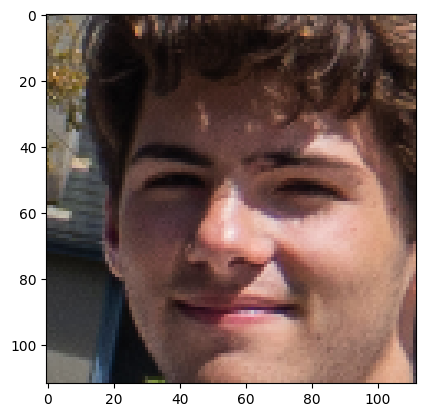

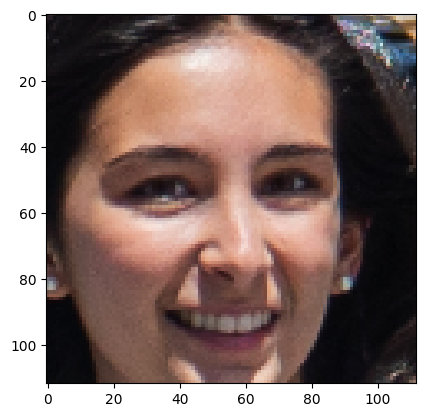

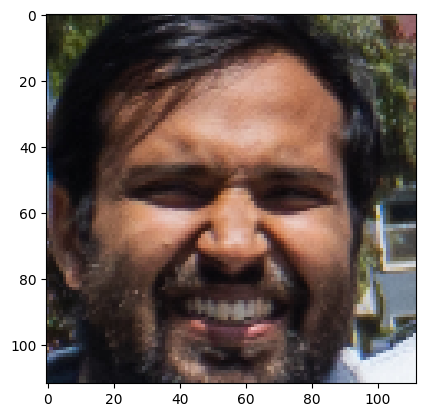

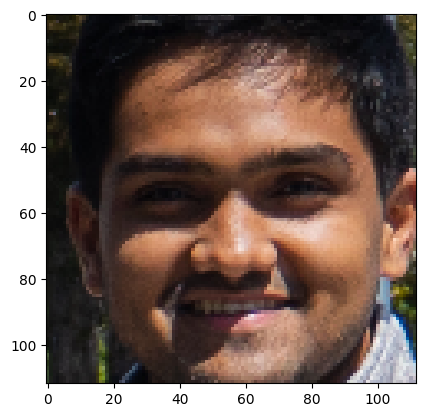

In [25]:
for image in aligned[1]:
    plt.imshow(image)
    plt.show()

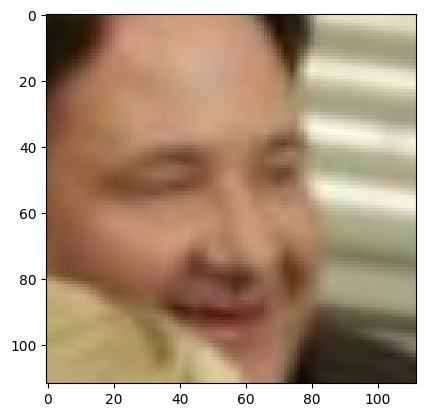

In [20]:
plt.imshow(aligned[1][1])

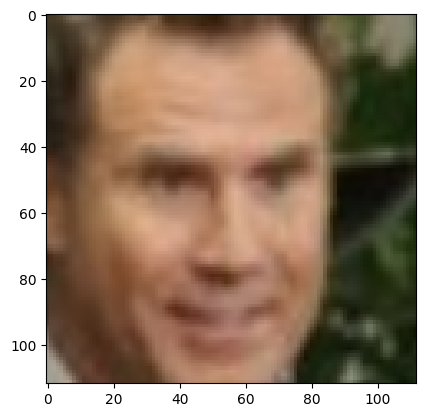

In [21]:
plt.imshow(aligned[1][0])

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

def draw_yxyx_bboxes(image_path, bboxes):
    """
    Draw xyxyn bounding boxes on the image with numbering.
    
    Args:
        image_path (str): Path to the image file.
        bboxes (ndarray): Bounding boxes in normalized xyxyn format (n, 4).
                          Each row is (x_min, y_min, x_max, y_max) normalized [0,1].
    """
    # Load the image (OpenCV loads as BGR, convert to RGB for plt)
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w, _ = img_rgb.shape
    
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img_rgb)
    
    for idx, (x_min, y_min, x_max, y_max) in enumerate(bboxes, start=1):
        # Convert normalized coordinates to pixel values
        x_min_px = x_min * w
        y_min_px = y_min * h
        box_w = (x_max - x_min) * w
        box_h = (y_max - y_min) * h
        
        # Draw rectangle
        rect = patches.Rectangle(
            (x_min_px, y_min_px),
            box_w,
            box_h,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add numbering
        ax.text(
            x_min_px, y_min_px - 5,
            str(idx),
            color='yellow',
            fontsize=12,
            backgroundcolor='black'
        )
    
    plt.axis('off')
    plt.show()


In [8]:
img_sample = "data/group_test/office1.jpg"

In [9]:
import os

def list_images_in_folder(folder, extensions=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
    """
    Return a list of full paths to images in the given folder.

    Args:
        folder (str): Path to folder.
        extensions (tuple): File extensions to include (case-insensitive).

    Returns:
        list[str]: Full paths to matching image files.
    """
    image_paths = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(extensions)
    ]
    return image_paths


In [3]:
imgs_paths = list_images_in_folder("data/group_test")

In [5]:
model_name="edgeface_s_gamma_05" # or edgeface_xs_gamma_06
model=get_model(model_name)
checkpoint_path=f'checkpoints/{model_name}.pt'
model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
model.eval()




TimmFRWrapperV2(
  (model): EdgeNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 48, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((48,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): EdgeNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvBlock(
            (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48)
            (norm): LayerNorm((48,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): LoRaLin(
                (linear1): Linear(in_features=48, out_features=24, bias=False)
                (linear2): Linear(in_features=24, out_features=192, bias=True)
              )
              (act): GELU(approximate='none')
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): LoRaLin(
                (linear1): Linear(in_features=192, out_features=24, bias=False)
                (linea

In [10]:
detector = mtcnn.MTCNN(device='cpu')

In [12]:
detector??

Type:        MTCNN
String form: <mtcnn.MTCNN object at 0x000002148786A1E0>
File:        e:\synclabs\edgeface\face_alignment\mtcnn.py
Source:     
class MTCNN():
    def __init__(self, device: str = 'cuda:0', crop_size: Tuple[int, int] = (112, 112)):

        assert device in ['cuda:0', 'cpu']
        self.device = torch.device(device)
        assert crop_size in [(112, 112), (96, 112)]
        self.crop_size = crop_size

        # change working dir to this file location to load npz files. Then switch back
        cwd = os.getcwd()
        os.chdir(os.path.dirname(__file__))

        self.pnet = PNet().to(self.device)
        self.rnet = RNet().to(self.device)
        self.onet = ONet().to(self.device)
        self.pnet.eval()
        self.rnet.eval()
        self.onet.eval()
        self.refrence = get_reference_facial_points(default_square=crop_size[0] == crop_size[1])

        self.min_face_size = 20
        self.thresholds =  [0.6,0.7,0.9]
        self.nms_thresholds = [0.7, 0.7, 0

In [99]:
def adjust_mtcnn_box(box, image_shape, margin_ratio=0.05, square=True):

    """
    Adjusts MTCNN boxes to add margin and optionally convert to square.
    
    Args:
        box: np.ndarray of shape (n, 4) where each row is [x1, y1, x2, y2].
        margin_ratio: Percent of box size to add as padding.
        square: Whether to convert to square box.
    
    Returns:
        np.ndarray: Adjusted boxes of shape (n, 4) where each row is [x1, y1, x2, y2].
    """
    # Unpack box coordinates
    x1, y1, x2, y2 = box[:, 0], box[:, 1], box[:, 2], box[:, 3]
    
    # Calculate center (cx, cy) and size (width, height)
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    w, h = x2 - x1, y2 - y1
    size = torch.maximum(w, h)
    
    if square:
        size = size * (1 + margin_ratio)
    else:
        w *= (1 + margin_ratio)
        h *= (1 + margin_ratio)
        size = torch.maximum(w, h)
    
    # Calculate adjusted coordinates
    x1 = torch.maximum(torch.tensor(0), cx - size / 2)
    y1 = torch.maximum(torch.tensor(0), cy - size / 2)
    x2 = torch.minimum(torch.tensor(image_shape[1]), cx + size / 2)
    y2 = torch.minimum(torch.tensor(image_shape[0]), cy + size / 2)
    out = torch.stack([x1, y1, x2, y2], axis=-1,)
    # Return adjusted boxes as numpy array
    return torch.tensor(out.detach(), dtype=torch.int)

def crop_and_resize_bboxes(image: np.ndarray, bboxes: torch.Tensor, target_size: int = 112):
    """
    Crops and resizes the bounding boxes from the original image (given as a NumPy array).

    Args:
        image (np.ndarray): The input image as a NumPy array of shape (H, W, C).
        bboxes (torch.Tensor): Tensor of bounding boxes of shape (n, 4), where each row is [x1, y1, x2, y2].
        target_size (int): The size to which the cropped regions should be resized. Default is 112.

    Returns:
        torch.Tensor: A tensor of cropped and resized images of shape (n, C, target_size, target_size).
    """
    # Convert the NumPy array to a PyTorch tensor
    image_tensor = torch.tensor(image).permute(2, 0, 1)  # Convert (H, W, C) to (C, H, W)

    # Initialize a transform for resizing
    resize_transform = T.Resize((target_size, target_size))

    # List to store cropped and resized images
    cropped_resized_images = []

    # Loop through each bounding box
    for bbox in bboxes:
        x1, y1, x2, y2 = bbox.int()  # Convert to integer values for indexing

        # Crop the image using the bounding box
        cropped_image = image_tensor[:, y1:y2, x1:x2]

        # Resize the cropped image to the target size
        resized_image = resize_transform(cropped_image)

        # Append the resized image to the list
        resized_image = resized_image.permute(1, 2, 0).numpy()
   
        if resized_image.shape[2] == 3:  # Check if the image has 3 channels (RGB)
            resized_image = resized_image[..., ::-1]
        cropped_resized_images.append(resized_image)

    # Stack all cropped and resized images into a single tensor
    return np.stack(cropped_resized_images)

In [112]:
def transform_stack_of_images(image_stack: np.ndarray):
    # Convert the NumPy array of shape (n, H, W, C) to a PyTorch tensor of shape (n, C, H, W)
    image_stack_tensor = torch.tensor(image_stack).permute(0, 3, 1, 2).float()  # shape: (n, C, H, W)

    # Define the transformation (Normalize and ToTensor are already applied by converting to tensor)
    transform = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

    # Apply normalization to the entire batch in parallel
    transformed_stack = transform(image_stack_tensor)

    return transformed_stack

In [117]:
def get_faces_n_emb(path):
    face_res = face_model.predict(path)
    bboxes =face_res[0].boxes.xyxy.int()
    face_corners = adjust_mtcnn_box(bboxes, face_res[0].orig_img.shape)
    faces = crop_and_resize_bboxes(face_res[0].orig_img, face_corners)
    t_faces = transform_stack_of_images(faces)
    embeddings = model(t_faces)
    return faces, embeddings


In [140]:
import os
import torch
from torchvision import transforms
from PIL import Image
import numpy as np

def get_emb_from_fodler(folder_path, transform):
    embeddings_list = []  # List to store embeddings for all faces
    
    # Loop through all images in the folder
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        
        # Check if the file is an image (optional, depending on the image types you want to process)
        if filename.lower().endswith(('png', 'jpg', 'jpeg', 'bmp', 'gif')):
            # Get faces and embeddings for the image
            try:
                aligned = align.get_aligned_face(image_path) # align face
                transformed_input = transform(aligned)
                emb = model(transformed_input[None])
                embeddings_list.append(emb)
            except :
                print("error loading this image")
    embeddings_list = torch.stack(embeddings_list)
    return embeddings_list

In [182]:
faces , embeddings = get_faces_n_emb('data/hacker_house/DSC03157.jpg')


image 1/1 e:\synclabs\edgeface\data\hacker_house\DSC03157.jpg: 448x640 5 faces, 13.7ms
Speed: 2.8ms preprocess, 13.7ms inference, 5.5ms postprocess per image at shape (1, 3, 448, 640)


E:\Temp\ipykernel_25452\1229997648.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(out.detach(), dtype=torch.int)


In [135]:
transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
            ])

In [183]:
jacob_emb = get_emb_from_fodler("data/jacob", transform)

Face detection Failed due to error.
list index out of range
error loading this image
Face detection Failed due to error.
list index out of range
error loading this image


In [184]:
jacob_emb = jacob_emb.squeeze(1)

In [144]:
jacob_emb = jacob_emb[:4]

In [185]:
def cosine_similarity_matrix(A, B):
    """
    Compute the cosine similarity matrix between two sets of vectors.
    
    Arguments:
    A -- n1 x d array of vectors (n1 vectors, each of dimension d)
    B -- n2 x d array of vectors (n2 vectors, each of dimension d)
    
    Returns:
    cosine_sim_matrix -- n1 x n2 matrix where entry (i, j) is the cosine similarity 
                          between vector A[i] and B[j]
    """
    # Ensure A and B are numpy arrays
    A = np.array(A)
    B = np.array(B)
    
    # Compute the dot product between each pair of vectors from A and B
    dot_product = np.dot(A, B.T)  # A is n1 x d, B is n2 x d, so A @ B.T is n1 x n2
    
    # Compute the norms (magnitudes) of A and B
    norm_A = np.linalg.norm(A, axis=1, keepdims=True)  # n1 x 1
    norm_B = np.linalg.norm(B, axis=1, keepdims=True)  # n2 x 1
    
    # Compute the cosine similarity matrix
    cosine_sim_matrix = dot_product / (norm_A * norm_B.T)  # n1 x n2
    
    return cosine_sim_matrix

In [186]:
sim = cosine_similarity_matrix(jacob_emb.detach().numpy(), embeddings.detach().numpy())

In [187]:
image_paths = list_image_paths('data/hacker_house')

In [188]:
def l2_distance_matrix(H1, H2):
    return np.sqrt(((H1[:, None, :] - H2[None, :, :]) ** 2).sum(axis=2))

In [189]:
def find_right_face(frame_emb, source_emb):
    mat = cosine_similarity_matrix(frame_emb, source_emb)
    idxes = np.argmax(mat, axis= 0)
    scores = np.max(mat, axis=0)
    mask = scores > 0
    idxes = idxes[mask]
    scores = scores[mask]
    unique_matches = np.unique(idxes)
    sums = np.array([scores[idxes == obj].sum() for obj in unique_matches])
    best_idx = unique_matches[np.argmax(sums)]
    return best_idx


image 1/1 e:\synclabs\edgeface\data\hacker_house\DSC03157.jpg: 448x640 5 faces, 14.6ms
Speed: 3.6ms preprocess, 14.6ms inference, 6.0ms postprocess per image at shape (1, 3, 448, 640)


E:\Temp\ipykernel_25452\1229997648.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(out.detach(), dtype=torch.int)


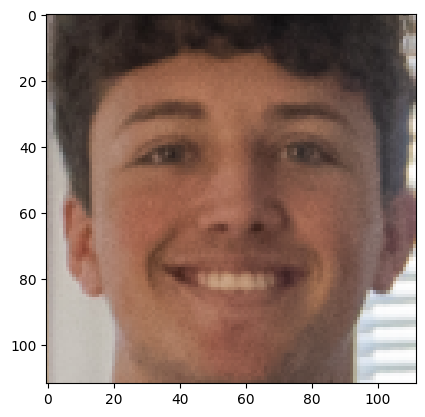


image 1/1 e:\synclabs\edgeface\data\hacker_house\DSC03158.jpg: 448x640 6 faces, 14.5ms
Speed: 3.2ms preprocess, 14.5ms inference, 6.9ms postprocess per image at shape (1, 3, 448, 640)


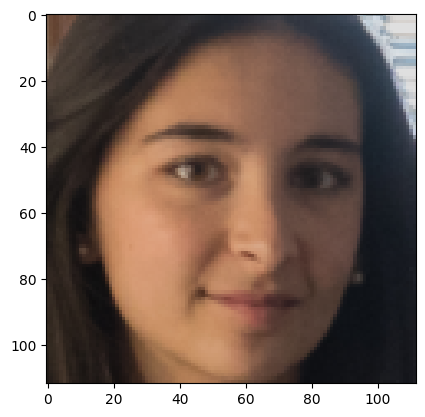


image 1/1 e:\synclabs\edgeface\data\hacker_house\DSC03162.jpg: 448x640 5 faces, 12.6ms
Speed: 2.7ms preprocess, 12.6ms inference, 6.7ms postprocess per image at shape (1, 3, 448, 640)


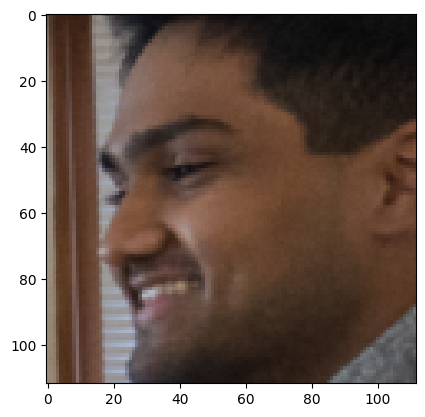


image 1/1 e:\synclabs\edgeface\data\hacker_house\DSC03170.jpg: 448x640 5 faces, 12.7ms
Speed: 2.8ms preprocess, 12.7ms inference, 5.4ms postprocess per image at shape (1, 3, 448, 640)


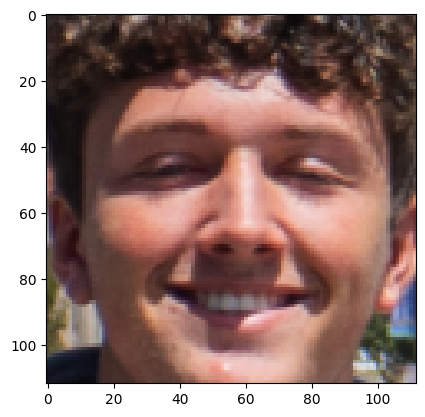

In [190]:
for path in image_paths:
    faces , embeddings = get_faces_n_emb(path)
    best_idx = find_right_face(embeddings.detach().numpy(), jacob_emb.detach().numpy())
    plt.imshow(faces[best_idx])
    plt.show()